# 04. PyTorch Custom Dataset

This notebook builds an image classification workflow on the Fashion MNIST dataset using PyTorch and TorchVision — covering data loading, a baseline linear model, and a full training/evaluation loop.

- `torchvision.datasets` — provides ready-to-use vision datasets with built-in train/test splits
- `torch.utils.data.DataLoader` — batches and shuffles data for training
- `nn.Sequential` — chains layers into a simple feed-forward model

**Note:** This notebook trains on CPU by default; a CUDA/ROCm device is only used if detected in the setup cell.

**Resources**
1. Notebook: https://www.learnpytorch.io/04_pytorch_custom_datasets/
2. Video: https://www.youtube.com/watch?v=V_xro1bcAuA&t=5277s

## Setup & Environment Check

Import the core libraries and detect the available device up front so every tensor and model can be moved to the right place later in the notebook.

- `torch.cuda.is_available()` — checks for a CUDA/ROCm-capable GPU and falls back to CPU otherwise
- `warnings.filterwarnings("ignore")` — suppresses noisy library warnings so the output stays readable
- `DEVICE` — global variable set here and reused throughout the notebook for `.to(DEVICE)` calls

**Note:** This model is trained entirely on `"cpu"` later in the notebook — `DEVICE` is detected here for reference and timing comparisons, not used to move the model or data.

In [35]:
# Capture runtime details so later cells can choose the right device.
import platform
import torch
from torch import nn
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torchvision
from torchvision  import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

# Keep notebook output focused on the example results.
warnings.filterwarnings("ignore")

print(f"--- System Information ---")
print(f"Platform: {platform.platform()}")
print(f"Python:   {platform.python_version()}")
print(f"PyTorch:  {torch.__version__}")

print(f"\n--- GPU/ROCm Accelerators ---")
cuda_available = torch.cuda.is_available()
print(f"CUDA Available: {cuda_available}")

if cuda_available:
    print(f"Device Count:   {torch.cuda.device_count()}")
    print(f"Primary Device: {torch.cuda.get_device_name(0)}")
    DEVICE = torch.device("cuda:0")
else:
    print("Optimization Note: No CUDA-capable GPU detected. Training and inference will use the CPU.")
    DEVICE = torch.device("cpu")


--- System Information ---
Platform: Windows-11-10.0.26200-SP0
Python:   3.12.13
PyTorch:  2.9.1+rocm7.2.1

--- GPU/ROCm Accelerators ---
CUDA Available: True
Device Count:   1
Primary Device: AMD Radeon RX 7900 XT


### Downloading a Dataset (Getting the Data)

Subset dataset (3 classes, 1000 images per class consisting of 750 training and 250 testing images)
- Source: "https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip"

In [36]:
import requests
import zipfile
from pathlib import Path

# Download the dataset and extract it to a local directory
data_dir = Path("data")
images_dir = data_dir / "pizza_steak_sushi"

# Download the dataset if it doesn't already exist
if images_dir.exists():
    print(f"Dataset already exists at {images_dir}. Skipping download.")
else:
    print(f"Downloading dataset to {images_dir}...")
    url = "https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip"
    response = requests.get(url)
    with open(data_dir / "pizza_steak_sushi.zip", "wb") as f:
        f.write(response.content)
    with zipfile.ZipFile(data_dir / "pizza_steak_sushi.zip", "r") as zip_ref:
        zip_ref.extractall(images_dir)

Dataset already exists at data\pizza_steak_sushi. Skipping download.


### Data exploration

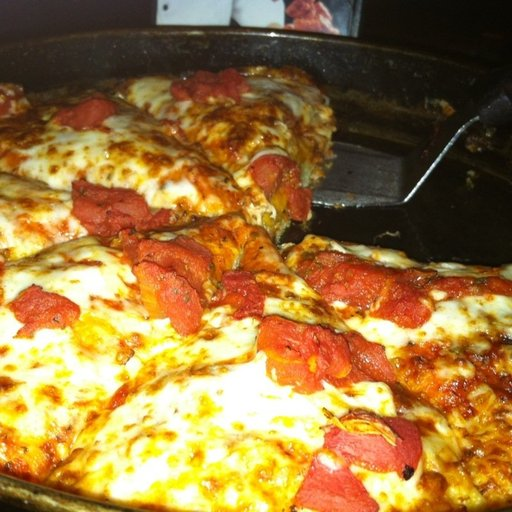

In [37]:
from IPython.display import display,HTML
from PIL import Image
# Display a sample image from the dataset
sample_image_path = "data/pizza_steak_sushi/train/pizza/1044789.jpg"

with Image.open(sample_image_path) as i:
    display(i)

In [38]:
import os
def walk_through_dir(dir_path, sample_size=5):
    """
    Walks through a directory and prints out its contents.
    """
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"Found directory: {dirpath}")
        for file_name in filenames[:sample_size]:
            print(f"\t{file_name}")

walk_through_dir(images_dir, sample_size=10)

Found directory: data\pizza_steak_sushi
Found directory: data\pizza_steak_sushi\test
Found directory: data\pizza_steak_sushi\test\pizza
	1152100.jpg
	1503858.jpg
	1687143.jpg
	1925494.jpg
	194643.jpg
	195160.jpg
	2003290.jpg
	2019408.jpg
	2111981.jpg
	2124579.jpg
Found directory: data\pizza_steak_sushi\test\steak
	100274.jpg
	1016217.jpg
	1285886.jpg
	1302563.jpg
	1627703.jpg
	1868005.jpg
	1882831.jpg
	2117351.jpg
	2144308.jpg
	27415.jpg
Found directory: data\pizza_steak_sushi\test\sushi
	1172255.jpg
	1230335.jpg
	1245193.jpg
	1434806.jpg
	1600999.jpg
	1680893.jpg
	1742201.jpg
	175783.jpg
	1987407.jpg
	207578.jpg
Found directory: data\pizza_steak_sushi\train
Found directory: data\pizza_steak_sushi\train\pizza
	1008844.jpg
	1033251.jpg
	1044789.jpg
	1089334.jpg
	1105700.jpg
	12301.jpg
	1285298.jpg
	138855.jpg
	1412034.jpg
	1524655.jpg
Found directory: data\pizza_steak_sushi\train\steak
	100135.jpg
	1225762.jpg
	1257104.jpg
	1264154.jpg
	1382427.jpg
	1413972.jpg
	1598345.jpg
	1615395.jpg

In [39]:
# Setting train and test directories
train_dir = images_dir / "train"
test_dir = images_dir / "test"

train_dir, test_dir

(WindowsPath('data/pizza_steak_sushi/train'),
 WindowsPath('data/pizza_steak_sushi/test'))

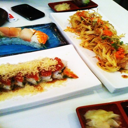

Image path: data\pizza_steak_sushi\train\sushi\148799.jpg
Label: sushi
Original Image size: (384, 512)



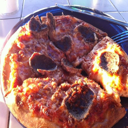

Image path: data\pizza_steak_sushi\train\pizza\2382016.jpg
Label: pizza
Original Image size: (512, 512)



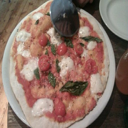

Image path: data\pizza_steak_sushi\train\pizza\1285298.jpg
Label: pizza
Original Image size: (512, 341)



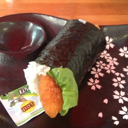

Image path: data\pizza_steak_sushi\train\sushi\2720223.jpg
Label: sushi
Original Image size: (512, 512)



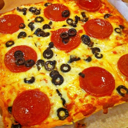

Image path: data\pizza_steak_sushi\train\pizza\715169.jpg
Label: pizza
Original Image size: (512, 512)



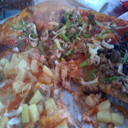

Image path: data\pizza_steak_sushi\train\pizza\38349.jpg
Label: pizza
Original Image size: (512, 384)



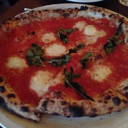

Image path: data\pizza_steak_sushi\train\pizza\3505182.jpg
Label: pizza
Original Image size: (512, 512)



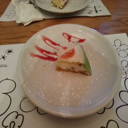

Image path: data\pizza_steak_sushi\train\pizza\2576168.jpg
Label: pizza
Original Image size: (512, 384)



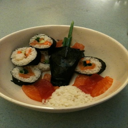

Image path: data\pizza_steak_sushi\train\sushi\268990.jpg
Label: sushi
Original Image size: (384, 512)



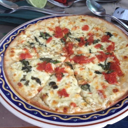

Image path: data\pizza_steak_sushi\train\pizza\2291093.jpg
Label: pizza
Original Image size: (512, 512)



In [40]:
# Visualize the first 10 images from the training dataset
import random
from PIL import Image

random.seed(42)

image_path_list = list(train_dir.glob("*/*.jpg")) # glob means to find all the files with the given pattern
random_image_paths = random.sample(image_path_list, 10)

for image_path in random_image_paths:
    with Image.open(image_path) as img:
        display(img.resize((128, 128)))
        print(f"Image path: {image_path}\nLabel: {image_path.parent.name}\nOriginal Image size: {img.size}\n")

### Turning images into tensors (Data Transformation)

In [41]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

# Turning the images into tensors
data_transform = transforms.Compose([
    
    # Resize the images to 128x128 pixels
    transforms.Resize((128, 128)),

    transforms.RandomHorizontalFlip(0.5),  # Randomly flip the images horizontally (50% of the time)

    # Convert the images to PyTorch tensors
    transforms.ToTensor()
])


# Option 1: Use the ImageFolder dataset class to load the training data
train_data = datasets.ImageFolder(root=train_dir, 
                                  transform=data_transform,         # A function/transform that takes in a PIL image and returns a transformed version. E.g, transforms.RandomCrop
                                  target_transform=None             # A function/transform that takes in the target and transforms it. E.g. one-hot encoding
)

test_data = datasets.ImageFolder(root=test_dir,
                                 transform=data_transform,       
                                 target_transform=None)

train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data\pizza_steak_sushi\train
     StandardTransform
 Transform: Compose(
                Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data\pizza_steak_sushi\test
     StandardTransform
 Transform: Compose(
                Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [42]:
class_names = train_data.classes
class_dict = train_data.class_to_idx

class_names, class_dict

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [43]:
train_data[0][0], train_data[0][0].shape, train_data[0][0].dtype

(tensor([[[0.1137, 0.1098, 0.1098,  ..., 0.1059, 0.1137, 0.1137],
          [0.1255, 0.1216, 0.1216,  ..., 0.1059, 0.1098, 0.1137],
          [0.1333, 0.1294, 0.1294,  ..., 0.1020, 0.1059, 0.1098],
          ...,
          [0.1765, 0.1686, 0.1647,  ..., 0.0902, 0.0863, 0.0824],
          [0.1765, 0.1686, 0.1647,  ..., 0.0824, 0.0863, 0.0902],
          [0.1608, 0.1569, 0.1569,  ..., 0.0824, 0.0824, 0.0863]],
 
         [[0.0588, 0.0549, 0.0549,  ..., 0.0706, 0.0745, 0.0706],
          [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
          [0.0667, 0.0627, 0.0627,  ..., 0.0745, 0.0745, 0.0745],
          ...,
          [0.2314, 0.2275, 0.2275,  ..., 0.1098, 0.1098, 0.1059],
          [0.2314, 0.2314, 0.2275,  ..., 0.1020, 0.1020, 0.1059],
          [0.2275, 0.2275, 0.2353,  ..., 0.0980, 0.0980, 0.1020]],
 
         [[0.0196, 0.0196, 0.0196,  ..., 0.0902, 0.0980, 0.0941],
          [0.0235, 0.0235, 0.0235,  ..., 0.0902, 0.0941, 0.0941],
          [0.0196, 0.0157, 0.0196,  ...,

In [44]:
# Turn images into DataLoaders
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=32,      # Number of samples per batch
                              num_workers=os.cpu_count(),    # Number of subprocesses to use for data loading. 0 means that the data will be loaded in the main process.
                                shuffle=True)       # Whether to shuffle the data after every epoch

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=32,
                             num_workers=os.cpu_count(),
                                shuffle=False)

print(train_dataloader, test_dataloader)
print(f"Number of batches in train_dataloader: {len(train_dataloader)}")
print(f"Number of batches in test_dataloader: {len(test_dataloader)}")

<torch.utils.data.dataloader.DataLoader object at 0x000001D6B4DF2EA0> <torch.utils.data.dataloader.DataLoader object at 0x000001D6B4B056A0>
Number of batches in train_dataloader: 8
Number of batches in test_dataloader: 3


In [45]:
img, label = next(iter(train_dataloader))

print(img.shape, label.shape)

torch.Size([32, 3, 128, 128]) torch.Size([32])


In [46]:
# Option 2: Create a custom dataset class to load the training data (More code is needed to implement this option)
from typing import Tuple, List, Dict


target_directory = train_dir
print(f"Target directory: {target_directory}")

class_names_found = sorted([entry.name for entry in list(os.scandir(target_directory))])
class_names_found

Target directory: data\pizza_steak_sushi\train


['pizza', 'steak', 'sushi']

In [47]:
list(os.scandir(target_directory))

[<DirEntry 'pizza'>, <DirEntry 'steak'>, <DirEntry 'sushi'>]

In [48]:
def find_classes_in_directory(directory: str) -> Tuple[List[str], Dict[str, int]]:
    """
    Finds the class names and their corresponding indices in a given directory.

    Args:
        directory (str): The path to the directory containing class subdirectories.

    Returns:
        Tuple[List[str], Dict[str, int]]: A tuple containing a list of class names and a dictionary mapping class names to indices.
    """
    class_names = sorted([entry.name for entry in os.scandir(directory) if entry.is_dir()])
    class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
    return class_names, class_to_idx

find_classes_in_directory(target_directory)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [49]:
# Creation of a custom dataset class to replicate the functionality of ImageFolder
from torch.utils.data import Dataset
import pathlib
# Subclass torch.utils.data.Dataset to create a custom dataset class
class CustomDataset(Dataset):
    # Initialize our custom dataset
    def __init__(self, target_dir: str, transform=None):
        # Create class attributes
        self.paths = list(pathlib.Path(target_dir).glob("*/*.jpg"))  # List of all image paths in the dataset
        # Setup transform
        self.transform = transform
        # Create classes and class_to_idx attributes
        self.classes, self.class_to_idx = find_classes_in_directory(target_dir)

    # Function to load an image from the given path
    def load_images(self, index: int) -> Image.Image:
        image_path = self.paths[index]
        return Image.open(image_path)
    
    # Override the __len__ method to return the number of samples in the dataset
    def __len__(self) -> int:
        "Returns the number of samples in the dataset."
        return len(self.paths)
    
    # Override the __getitem__ method to return a sample from the dataset
    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
        # Load the image
        image = self.load_images(index)
        class_name = self.paths[index].parent.name # expects the parent directory of the image to be the class name
        class_index = self.class_to_idx[class_name] # get the class index from the class name
        
        # Transform the image if a transform is provided
        if self.transform:
            return self.transform(image), class_index # return the transformed image and the class index
        else:
            return image, class_index # return the original image and the class index

In [50]:
# Create a transform to convert images to tensors and normalize them
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Resize the images to 128x128 pixels
    transforms.RandomHorizontalFlip(0.5),  # Randomly flip the images horizontally (50% of the time)
    transforms.ToTensor()  # Convert the images to PyTorch tensors
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Resize the images to 128x128
    transforms.ToTensor()  # Convert the images to PyTorch tensors
])

In [51]:
# Test the custom dataset class by creating an instance of it and checking the first sample
train_data_custom = CustomDataset(target_dir=train_dir, transform=train_transform)

test_data_custom = CustomDataset(target_dir=test_dir, transform=test_transform)

print(train_data_custom, test_data_custom)
print(f"Samples in train_data_custom: {len(train_data_custom)}\nSamples in train_data: {len(train_data)}")
print(f"Samples in test_data_custom: {len(test_data_custom)}\nSamples in test_data: {len(test_data)}")

<__main__.CustomDataset object at 0x000001D6B4E3FFB0> <__main__.CustomDataset object at 0x000001D6B56EF440>
Samples in train_data_custom: 225
Samples in train_data: 225
Samples in test_data_custom: 75
Samples in test_data: 75


In [52]:
def display_sample_from_custom_dataset(dataset: CustomDataset, classes: List[str] = None, n: int = 10, display_shape:bool = True, seed: int = None):
    """
    Displays a sample image and its label from the custom dataset.

    Args:
        dataset (CustomDataset): The custom dataset instance.
        index (int): The index of the sample to display.
    """
    if n > 10:
        n = 10
        display_shape = False
        print("Note: Displaying only 10 samples. Set n <= 10 to display more samples.")

    if seed:
        random.seed(seed)
    
    random_samples_idx = random.sample(range(len(dataset)), k=n)

    plt.figure(figsize=(16,8))

    for i, targ_sample in enumerate(random_samples_idx):
        target_image, target_label = dataset[targ_sample][0], dataset[targ_sample][1]

        target_image_adjust = target_image.permute(1, 2, 0)  # Change from (C, H, W) to (H, W, C) for displaying

        plt.subplot(1, n, i+1)
        plt.imshow(target_image_adjust)
        plt.axis("off")
        if classes:
            title = f"Label: {classes[target_label]}"
            if display_shape:
                title += f"\nShape: {target_image_adjust.shape}"
        plt.title(title)


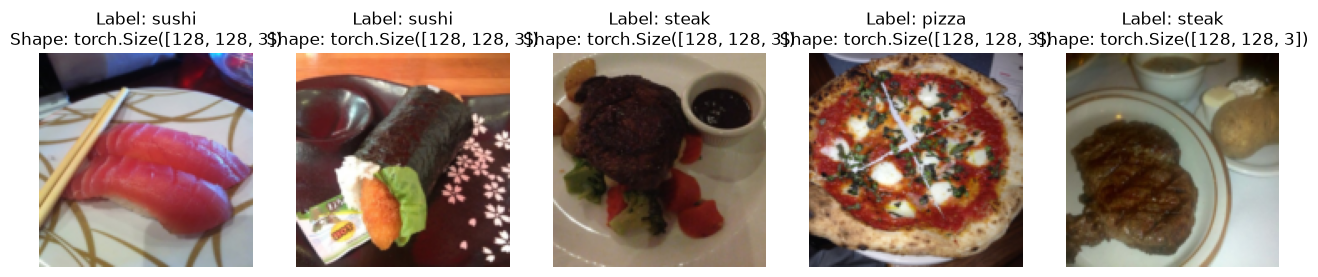

In [53]:
display_sample_from_custom_dataset(train_data, classes=train_data.classes, n=5, display_shape=True, seed=None)

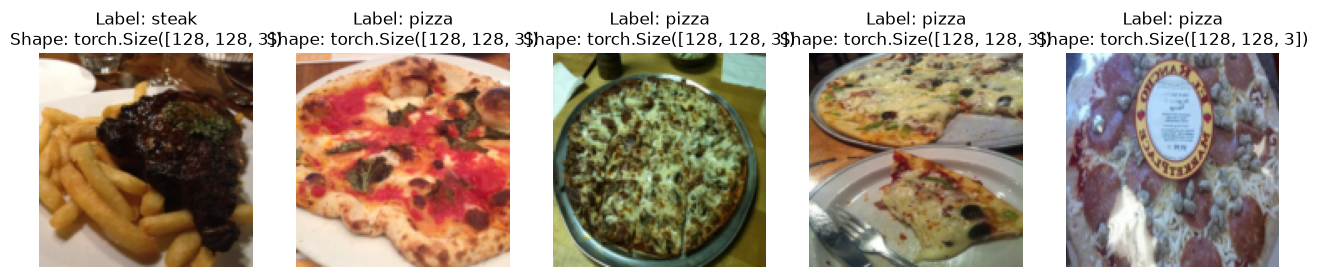

In [54]:
display_sample_from_custom_dataset(train_data_custom, classes=train_data_custom.classes, n=5, display_shape=True, seed=None)

In [55]:
BATCH_SIZE = 32
# Custom dataset classes defined in a notebook can fail with spawned workers on Windows, so keep this single-process.
NUM_WORKERS = 0
train_dataloader_custom = DataLoader(dataset=train_data_custom,
                                     batch_size=BATCH_SIZE,
                                        num_workers=NUM_WORKERS,
                                        shuffle=True)

test_dataloader_custom = DataLoader(dataset=test_data_custom,
                                    batch_size=BATCH_SIZE,
                                    num_workers=NUM_WORKERS,
                                        shuffle=False)

train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x1d6b54446e0>,
 <torch.utils.data.dataloader.DataLoader at 0x1d6b53d35f0>)

In [56]:
img_custom, label_custom = next(iter(train_dataloader_custom))

img_custom.shape, label_custom.shape

(torch.Size([32, 3, 128, 128]), torch.Size([32]))

### Data Augmentation

In [57]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Resize the images to 128x128 pixels
    transforms.TrivialAugmentWide(num_magnitude_bins=10), # Apply TrivialAugmentWide for data augmentation
    transforms.ToTensor()  # Convert the images to PyTorch tensors
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Resize the images to 128x128
    transforms.ToTensor()  # Convert the images to PyTorch tensors
])

train_transform, test_transform

(Compose(
     Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
     TrivialAugmentWide(num_magnitude_bins=10, interpolation=InterpolationMode.NEAREST, fill=None)
     ToTensor()
 ),
 Compose(
     Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
     ToTensor()
 ))

In [58]:
image_path

WindowsPath('data/pizza_steak_sushi/train/pizza/2291093.jpg')

### Baseline Model 0

In [59]:
# Baseline Model TinyVGG
# Step 1: Create a simple transform to resize the images and convert them to tensors
simple_transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Resize the images to 128x128
    transforms.ToTensor()  # Convert the images to PyTorch tensors
])

train_data_simple = datasets.ImageFolder(root=train_dir, transform=simple_transform)

test_data_simple = datasets.ImageFolder(root=test_dir, transform=simple_transform)

BATCH_SIZE = 32
NUM_WORKERS = 0

# Step 2: Create DataLoaders for the training and test datasets
train_dataloader_simple = DataLoader(dataset=train_data_simple,
                                     batch_size=BATCH_SIZE,
                                        num_workers=NUM_WORKERS,
                                        shuffle=True)

test_dataloader_simple = DataLoader(dataset=test_data_simple,
                                    batch_size=BATCH_SIZE,
                                    num_workers=NUM_WORKERS,
                                        shuffle=False)



In [60]:
class TinyVGG(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*32*32, out_features=output_shape)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))

In [61]:
torch.manual_seed(42)

model_0 = TinyVGG(input_shape=3, hidden_units=10, output_shape=len(train_data.classes)).to("cpu")

model_0, model_0.state_dict()

(TinyVGG(
   (conv_block_1): Sequential(
     (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (1): ReLU()
     (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (3): ReLU()
     (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
   )
   (conv_block_2): Sequential(
     (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (1): ReLU()
     (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (3): ReLU()
     (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
   )
   (classifier): Sequential(
     (0): Flatten(start_dim=1, end_dim=-1)
     (1): Linear(in_features=10240, out_features=3, bias=True)
   )
 ),
 OrderedDict([('conv_block_1.0.weight',
               tensor([[[[ 0.1471,  0.1597, -0.0451],
                         [ 0.1768, -0.0422,  0.0388],
                         [-0.0937,  0.1130,  0.1697]],
               
              

In [62]:
# Trying forward pass with a batch of images from the train_dataloader_simple

image_batch, label_batch = next(iter(train_dataloader_simple))
image_batch.shape, label_batch.shape

(torch.Size([32, 3, 128, 128]), torch.Size([32]))

In [63]:
model_0(image_batch)

tensor([[-0.0513,  0.0112,  0.0120],
        [-0.0507,  0.0100,  0.0135],
        [-0.0494,  0.0102,  0.0137],
        [-0.0570,  0.0082,  0.0103],
        [-0.0563,  0.0087,  0.0108],
        [-0.0508,  0.0103,  0.0118],
        [-0.0520,  0.0096,  0.0125],
        [-0.0595,  0.0120,  0.0099],
        [-0.0514,  0.0124,  0.0149],
        [-0.0535,  0.0134,  0.0140],
        [-0.0527,  0.0090,  0.0133],
        [-0.0511,  0.0103,  0.0165],
        [-0.0568,  0.0114,  0.0118],
        [-0.0523,  0.0066,  0.0125],
        [-0.0537,  0.0098,  0.0119],
        [-0.0518,  0.0088,  0.0116],
        [-0.0543,  0.0115,  0.0124],
        [-0.0567,  0.0090,  0.0069],
        [-0.0526,  0.0108,  0.0137],
        [-0.0543,  0.0116,  0.0115],
        [-0.0502,  0.0116,  0.0147],
        [-0.0539,  0.0106,  0.0122],
        [-0.0520,  0.0113,  0.0152],
        [-0.0514,  0.0066,  0.0121],
        [-0.0532,  0.0123,  0.0121],
        [-0.0542,  0.0102,  0.0113],
        [-0.0547,  0.0075,  0.0129],
 

In [64]:
# Using torchinfo to check the device of the model and the data
from torchinfo import summary

summary(model_0, input_size=[1, 3, 128, 128])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 64, 64]           --
│    └─Conv2d: 2-1                       [1, 10, 128, 128]         280
│    └─ReLU: 2-2                         [1, 10, 128, 128]         --
│    └─Conv2d: 2-3                       [1, 10, 128, 128]         910
│    └─ReLU: 2-4                         [1, 10, 128, 128]         --
│    └─MaxPool2d: 2-5                    [1, 10, 64, 64]           --
├─Sequential: 1-2                        [1, 10, 32, 32]           --
│    └─Conv2d: 2-6                       [1, 10, 64, 64]           910
│    └─ReLU: 2-7                         [1, 10, 64, 64]           --
│    └─Conv2d: 2-8                       [1, 10, 64, 64]           910
│    └─ReLU: 2-9                         [1, 10, 64, 64]           --
│    └─MaxPool2d: 2-10                   [1, 10, 32, 32]           --
├─Sequentia

### Training and Testing loops

In [67]:
def train_step(model: nn.Module, dataloader: DataLoader, loss_fn: nn.Module, optimizer: torch.optim.Optimizer, device: torch.device = "cpu"):
    """
    Performs a single training step (epoch) for the given model.

    Args:
        model (nn.Module): The PyTorch model to train.
        dataloader (DataLoader): DataLoader for the training data.
        loss_fn (nn.Module): Loss function to compute the loss.
        optimizer (torch.optim.Optimizer): Optimizer to update the model parameters.
        device (torch.device): Device to perform computations on (CPU or GPU).

    Returns:
        Tuple[float, float]: A tuple containing the average training loss and accuracy for the epoch.
    """
    # Set the model to training mode
    model.train()

    # Initialize variables to track loss and accuracy
    train_loss, train_acc = 0, 0

    # Iterate over batches of data
    for batch, (X, y) in enumerate(dataloader):
        # Move data to the specified device
        X, y = X.to(device), y.to(device)

        # Forward pass: compute predictions
        y_pred = model(X) # Output raw logits (scores for each class)

        # Compute the loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # Zero the gradients before backward pass
        optimizer.zero_grad()

        # Backward pass: compute gradients
        loss.backward()

        # Update model parameters
        optimizer.step()

        # Calculate accuracy for this batch
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1) # Convert logits to probabilities and then get the predicted class
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)

    # Calculate average loss and accuracy over all batches
    train_loss /= len(dataloader)
    train_acc /= len(dataloader)

    return train_loss, train_acc

def test_step(model: nn.Module, dataloader: DataLoader, loss_fn: nn.Module, device: torch.device = "cpu") -> Tuple[float, float]:
    """
    Performs a single evaluation step (epoch) for the given model.

    Args:
        model (nn.Module): The PyTorch model to evaluate.
        dataloader (DataLoader): DataLoader for the test data.
        loss_fn (nn.Module): Loss function to compute the loss.
        device (torch.device): Device to perform computations on (CPU or GPU).

    Returns:
        Tuple[float, float]: A tuple containing the average test loss and accuracy for the epoch.
    """
    # Set the model to evaluation mode
    model.eval()

    # Initialize variables to track loss and accuracy
    test_loss, test_acc = 0, 0

    # Disable gradient computation for evaluation
    with torch.inference_mode():
        # Iterate over batches of data
        for batch, (X, y) in enumerate(dataloader):
            # Move data to the specified device
            X, y = X.to(device), y.to(device)

            # Forward pass: compute predictions
            test_pred = model(X)

            # Compute the loss
            loss = loss_fn(test_pred, y)
            test_loss += loss.item()

            # Calculate accuracy for this batch
            test_pred_class = torch.argmax(torch.softmax(test_pred, dim=1), dim=1)
            test_acc += (test_pred_class == y).sum().item() / len(test_pred)

    # Calculate average loss and accuracy over all batches
    test_loss /= len(dataloader)
    test_acc /= len(dataloader)

    return test_loss, test_acc

## Video Timestamp

Reference point in the source tutorial video for this section of the notebook.

- `~23:17:46` — marks the "Creating training and testing loop functions" segment, useful for jumping back to the explanation if revisiting this notebook later